# Adult dataset operating modes with ResNet encoder

This notebook demonstrates MIMIC's main operating modes on the Adult/Census Income dataset using the PyTorch ResNet encoder.

Set `N_ROWS` to control the working sample size. The default is intentionally small enough for quick experimentation.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, mean_absolute_error

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src" / "mimic").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from mimic import MIMIC
from mimic.diagnostics import binary_classification_diagnostics, classical_mds_2d, pairwise_feature_plot

RANDOM_STATE = 42
N_ROWS = 300
rng = np.random.default_rng(RANDOM_STATE)

## Load and clean Adult

Adult has no real ID column, but it does contain sampling-weight and education-code columns that are not useful for this demonstration. `fnlwgt` has a very wide range and `education-num` duplicates information already present in `education`, so both are excluded.

In [2]:
adult = fetch_openml("adult", version=2, as_frame=True)
raw = adult.frame.copy()
raw = raw.replace("?", np.nan)

drop_columns = ["fnlwgt", "education-num"]
clean = raw.drop(columns=drop_columns).dropna().reset_index(drop=True)
clean["income"] = clean["class"].astype(str)
clean = clean.drop(columns=["class"])

sampled = clean.sample(n=2 * N_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)
df = sampled.iloc[:N_ROWS].reset_index(drop=True)
test_df = sampled.iloc[N_ROWS:].reset_index(drop=True)

regression_columns = ["age", "hours-per-week", "capital-gain", "capital-loss"]
classification_columns = [c for c in df.columns if c not in regression_columns]

dataset_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(df), len(test_df)],
        "columns": [df.shape[1], test_df.shape[1]],
        "income_<=50K": [
            df["income"].value_counts(normalize=True).get("<=50K", 0.0),
            test_df["income"].value_counts(normalize=True).get("<=50K", 0.0),
        ],
        "income_>50K": [
            df["income"].value_counts(normalize=True).get(">50K", 0.0),
            test_df["income"].value_counts(normalize=True).get(">50K", 0.0),
        ],
    }
)

display(dataset_summary.style.format({"income_<=50K": "{:.1%}", "income_>50K": "{:.1%}"}))
display(df.head())

,split,rows,columns,income_<=50K,income_>50K
0,train,300,13,74.0%,26.0%
1,test,300,13,75.0%,25.0%


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,19,Self-emp-not-inc,10th,Married-spouse-absent,Adm-clerical,Unmarried,Amer-Indian-Eskimo,Female,0,0,40,United-States,<=50K
1,45,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
2,47,Private,Assoc-voc,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,>50K
3,23,Private,Some-college,Never-married,Craft-repair,Other-relative,White,Male,0,0,40,United-States,<=50K
4,53,Local-gov,HS-grad,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K


## Fit from clean data

The model is fitted on clean complete rows using a ResNet encoder. Later cells create perturbed copies to test each operating mode.

In [4]:
mimic = MIMIC(
    columns={"regression": regression_columns, "classification": classification_columns},
    mode="direct", # modes: "identity", "direct", "factorised", "joint"
    capacity=0.1,
    random_state=RANDOM_STATE,
    verbose=True,
)
mimic.fit(df)
embedding = mimic.transform(df)
fit_summary = pd.DataFrame(
    {
        "quantity": ["training_rows", "embedding_rows", "embedding_dimensions", "modelled_columns"],
        "value": [len(df), embedding.shape[0], embedding.shape[1], len(regression_columns) + len(classification_columns)],
    }
)
display(fit_summary)

MIMIC init hyperparameters:
  capacity: 0.1
  columns:
    regression:
      - age
      - hours-per-week
      - capital-gain
      - capital-loss
    classification:
      - workclass
      - education
      - marital-status
      - occupation
      - relationship
      - race
      - sex
      - native-country
      - income
  decoder: None
  encoder: None
  generation_decode_mode: auto
  level: None
  mode: direct
  n_bootstrap: None
  n_jobs: None
  policy: None
  random_state: 42
  verbose: True
MIMIC resolved fit configuration:
  mode_: direct
  level_: 1
  capacity_: 0.1
  capacity_parameters_:
    embedding_dim: 14
    hidden_dim: 20
    n_layers: 2
    max_epochs: 39
    patience: 5
    batch_size: 54
    n_components: 2
    n_bootstrap: 1
    dropout: 0.020000000000000004
    learning_rate: 0.002382984704172844
    weight_decay: 1.995262314968882e-06
  n_bootstrap_: 1
  generation_decode_mode_config_: direct
  encoder_: ResNetEncoder
  decoder_: NeuralConditionalSampler
  po

,quantity,value
0,training_rows,300
1,embedding_rows,300
2,embedding_dimensions,182
3,modelled_columns,13


## 1. Missing-value imputation

Hide known values and measure how well MIMIC reconstructs them.

In [5]:
impute_columns = ["age", "hours-per-week", "workclass", "marital-status"]
masked = test_df.copy()
truth = []
for col in impute_columns:
    rows = rng.choice(masked.index, size=max(20, N_ROWS // 20), replace=False)
    truth.append(pd.DataFrame({"row": rows, "column": col, "true": test_df.loc[rows, col].to_numpy()}))
    masked.loc[rows, col] = np.nan
truth = pd.concat(truth, ignore_index=True)

reconstructed = mimic.impute(masked, columns=impute_columns)
truth["predicted"] = [reconstructed.loc[r, c] for r, c in zip(truth["row"], truth["column"])]

imputation_scores = []
for col in impute_columns:
    part = truth[truth["column"] == col]
    if col in regression_columns:
        score = mean_absolute_error(part["true"].astype(float), part["predicted"].astype(float))
        metric = "MAE"
    else:
        score = accuracy_score(part["true"].astype(str), part["predicted"].astype(str))
        metric = "accuracy"
    imputation_scores.append({"column": col, "metric": metric, "score": score})

imputation_scores = pd.DataFrame(imputation_scores)
imputation_examples = truth.head(12)
display(imputation_scores.style.format({"score": "{:.3f}"}))
display(imputation_examples)

,column,metric,score
0,age,MAE,12.042
1,hours-per-week,MAE,9.441
2,workclass,accuracy,0.450
3,marital-status,accuracy,0.850


,row,column,true,predicted
0,218,age,41,36.223464
1,211,age,59,34.8191
2,58,age,59,47.780611
3,284,age,47,38.497125
4,251,age,26,33.833127
5,223,age,54,40.566544
6,38,age,21,32.492662
7,25,age,52,38.332428
8,185,age,23,33.88276
9,152,age,29,32.32789


## 2. Data inconsistency check

Inject unrealistic numerical values beyond two standard deviations from the clean distribution and rank entries by prediction discrepancy.

In [6]:
corrupted = test_df.copy()
for col in ["age", "hours-per-week"]:
    corrupted[col] = corrupted[col].astype(float)

corruption_records = []
for col in ["age", "hours-per-week"]:
    rows = rng.choice(corrupted.index, size=max(10, N_ROWS // 50), replace=False)
    mu = test_df[col].mean()
    sigma = test_df[col].std()
    corrupted.loc[rows, col] = mu + 4 * sigma
    corruption_records.extend({"row_index": r, "column": col} for r in rows)
corruption_records = pd.DataFrame(corruption_records)

diagnostics = mimic.confidence(corrupted, columns=["age", "hours-per-week"])
merged_marker = diagnostics.merge(
    corruption_records.assign(was_corrupted=True),
    on=["row_index", "column"],
    how="left",
)["was_corrupted"]
diagnostics["was_corrupted"] = (merged_marker == True).to_numpy()

ranked = diagnostics.sort_values("discrepancy", ascending=False)
top_k = len(corruption_records)
precision_at_k = ranked.head(top_k)["was_corrupted"].mean()

inconsistency_summary = pd.DataFrame(
    {"metric": ["corrupted_entries", "precision_at_k"], "value": [top_k, precision_at_k]}
)
inconsistency_top = ranked[["row_index", "column", "observed", "prediction", "discrepancy", "was_corrupted"]].head(12)
display(inconsistency_summary.style.format({"value": "{:.3f}"}))
display(inconsistency_top.style.format({"observed": "{:.2f}", "prediction": "{:.2f}", "discrepancy": "{:.2f}"}))

,metric,value
0,corrupted_entries,20.000
1,precision_at_k,0.850


,row_index,column,observed,prediction,discrepancy,was_corrupted
162,162,age,92.09,29.98,62.11,True
440,140,hours-per-week,99.00,39.79,59.21,False
244,244,age,92.09,35.55,56.54,True
124,124,age,92.09,35.80,56.29,True
147,147,age,92.09,37.20,54.89,True
293,293,age,92.09,37.39,54.70,True
196,196,age,92.09,39.26,52.83,True
121,121,age,92.09,39.33,52.76,True
447,147,hours-per-week,90.63,39.78,50.86,True
345,45,hours-per-week,90.63,39.78,50.86,True


## 3. Supervised learning on income

Income prediction is represented as imputing a missing `income` target column.

,metric,value
0,accuracy,0.787
1,macro_f1,0.729
2,roc_auc,0.797
3,average_precision,0.650


,true_income,predicted_income
0,>50K,>50K
1,<=50K,<=50K
2,<=50K,<=50K
3,<=50K,<=50K
4,<=50K,<=50K
5,<=50K,>50K
6,<=50K,<=50K
7,<=50K,<=50K
8,>50K,<=50K
9,>50K,>50K


,prediction,confidence,entropy,probability_margin,vote_fraction
0,>50K,0.682,0.625,0.364,1.000
1,<=50K,0.997,0.020,0.994,1.000
2,<=50K,0.714,0.599,0.428,1.000
3,<=50K,0.978,0.104,0.957,1.000
4,<=50K,0.880,0.366,0.761,1.000
5,>50K,0.577,0.681,0.153,1.000
6,<=50K,0.984,0.084,0.967,1.000
7,<=50K,0.777,0.530,0.555,1.000
8,<=50K,0.985,0.079,0.970,1.000
9,>50K,0.653,0.645,0.307,1.000


predicted,<=50K,>50K
actual,,
<=50K,187,38
>50K,26,49


predicted,<=50K,>50K
actual,,
<=50K,62.3%,12.7%
>50K,8.7%,16.3%


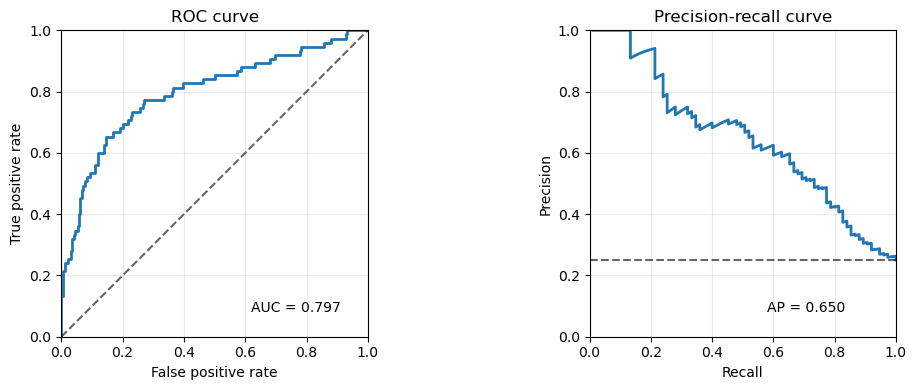

In [7]:
income_task = test_df.copy()
income_truth = test_df["income"].copy()
income_task["income"] = np.nan

income_pred = mimic.impute(income_task, columns=["income"])
y_true = income_truth.astype(str)
y_pred = income_pred["income"].astype(str)
income_confidence = mimic.confidence(income_task, columns=["income"])

income_diagnostics = binary_classification_diagnostics(
    y_true,
    y_pred,
    income_confidence,
    positive_label=">50K",
    negative_label="<=50K",
)
income_examples = pd.DataFrame(
    {"true_income": y_true.head(12).to_numpy(), "predicted_income": y_pred.head(12).to_numpy()}
)

display(income_diagnostics.metrics.style.format({"value": "{:.3f}"}))
display(income_examples)
display(
    income_confidence[["prediction", "confidence", "entropy", "probability_margin", "vote_fraction"]]
    .head(12)
    .style.format(
        {
            "confidence": "{:.3f}",
            "entropy": "{:.3f}",
            "probability_margin": "{:.3f}",
            "vote_fraction": "{:.3f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(income_diagnostics.roc_curve["fpr"], income_diagnostics.roc_curve["tpr"], linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", alpha=0.6)
axes[0].set_title("ROC curve")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].text(0.62, 0.08, f"AUC = {income_diagnostics.metrics.loc[income_diagnostics.metrics['metric'] == 'roc_auc', 'value'].iat[0]:.3f}")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].grid(alpha=0.25)
axes[0].set_aspect("equal", adjustable="box")

axes[1].plot(income_diagnostics.pr_curve["recall"], income_diagnostics.pr_curve["precision"], linewidth=2)
axes[1].axhline(income_diagnostics.positive_rate, linestyle="--", color="black", alpha=0.6)
axes[1].set_title("Precision-recall curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].text(0.58, 0.08, f"AP = {income_diagnostics.metrics.loc[income_diagnostics.metrics['metric'] == 'average_precision', 'value'].iat[0]:.3f}")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].grid(alpha=0.25)
axes[1].set_aspect("equal", adjustable="box")
fig.tight_layout()

display(income_diagnostics.confusion_counts.style.set_caption("Confusion table: absolute counts"))
display(
    income_diagnostics.confusion_relative.style
    .format("{:.1%}")
    .set_caption("Confusion table: relative counts")
)


## 4. Synthetic generation

Generate synthetic rows, inspect traceability, and compare original and generated distributions in a shared 2D projection.

In [8]:
synthetic, trace = mimic.sample(len(test_df), return_trace=True)

display(test_df.head(12).style.set_caption("Held-out test rows"))
display(synthetic.head(12).style.set_caption("Displacement-generated rows"))
display(trace.head(12).style.set_caption("Generation trace"))


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,35,Private,HS-grad,Married-civ-spouse,Transport-moving,Husband,White,Male,5178,0,90,United-States,>50K
1,21,Private,Preschool,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,50,Mexico,<=50K
2,47,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Wife,White,Female,0,0,40,Columbia,<=50K
3,25,Private,HS-grad,Divorced,Craft-repair,Own-child,White,Male,0,0,10,United-States,<=50K
4,37,Private,Assoc-voc,Never-married,Adm-clerical,Not-in-family,Other,Female,4101,0,35,United-States,<=50K
5,60,Private,5th-6th,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
6,35,Private,11th,Separated,Other-service,Unmarried,Black,Female,0,0,40,United-States,<=50K
7,33,Private,HS-grad,Divorced,Machine-op-inspct,Not-in-family,White,Male,0,0,49,United-States,<=50K
8,42,Local-gov,Assoc-acdm,Divorced,Protective-serv,Not-in-family,Asian-Pac-Islander,Male,0,0,48,United-States,>50K
9,34,Private,Prof-school,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,55,United-States,>50K


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,37,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,543,5,40,United-States,>50K
1,36,Private,Bachelors,Never-married,Prof-specialty,Not-in-family,White,Female,452,4,40,United-States,<=50K
2,39,Self-emp-not-inc,Some-college,Married-civ-spouse,Adm-clerical,Husband,White,Male,559,6,40,United-States,<=50K
3,53,Private,Bachelors,Married-civ-spouse,Transport-moving,Husband,White,Male,561,4,40,Mexico,>50K
4,42,Private,HS-grad,Separated,Craft-repair,Not-in-family,White,Female,395,3,40,United-States,<=50K
5,30,Private,HS-grad,Never-married,Adm-clerical,Not-in-family,White,Male,539,7,40,United-States,<=50K
6,27,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Female,419,3,40,United-States,<=50K
7,46,Private,HS-grad,Married-civ-spouse,Transport-moving,Husband,White,Male,430,4,40,United-States,>50K
8,73,Private,HS-grad,Separated,Other-service,Unmarried,White,Male,423,3,40,United-States,<=50K
9,37,Private,Bachelors,Divorced,Other-service,Not-in-family,White,Male,395,4,40,United-States,<=50K


,trace_type,sample_index,method,anchor_index,displacement_from_index,displacement_to_index,lambda,neighbour_mode,restriction,condition,decoder,generation_decode_mode,resolved_generation_decode_mode,random_state
0,embedding,0,displacement,26,291,101,0.469439,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
1,embedding,1,displacement,257,60,293,0.297089,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
2,embedding,2,displacement,157,131,157,0.630570,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
3,embedding,3,displacement,215,209,215,0.314057,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
4,embedding,4,displacement,135,192,135,0.713382,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
5,embedding,5,displacement,234,200,234,0.661381,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
6,embedding,6,displacement,133,127,170,0.527292,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
7,embedding,7,displacement,266,289,266,0.663816,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
8,embedding,8,displacement,189,235,189,0.427263,mutual,basic,None,NeuralConditionalSampler,auto,direct,42
9,embedding,9,displacement,20,166,224,0.696561,mutual,basic,None,NeuralConditionalSampler,auto,direct,42


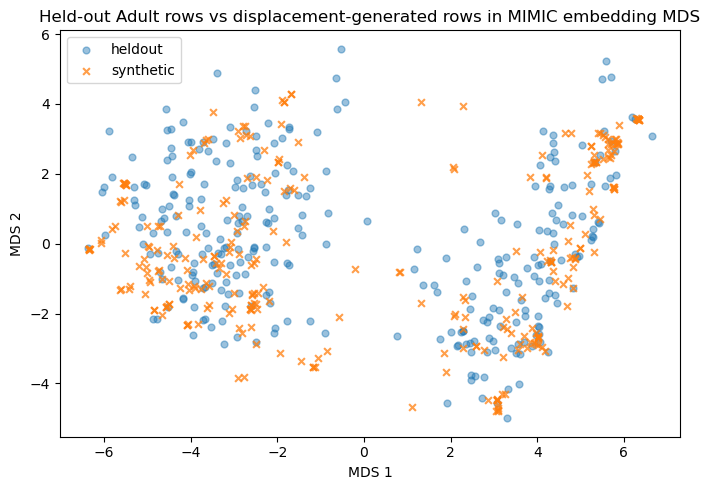

In [9]:
combined = pd.concat(
    [test_df.assign(source="heldout"), synthetic.assign(source="synthetic")],
    ignore_index=True,
)

# Use MIMIC's fitted embedding for both original and generated rows, then project jointly with classical MDS.
H_combined = mimic.transform(combined.drop(columns=["source"]))
plot_df = classical_mds_2d(H_combined, random_state=RANDOM_STATE)
plot_df["source"] = combined["source"].to_numpy()

fig, ax = plt.subplots(figsize=(7, 5))
for source, marker, alpha in [("heldout", "o", 0.45), ("synthetic", "x", 0.75)]:
    part = plot_df[plot_df["source"] == source]
    ax.scatter(part["mds1"], part["mds2"], label=source, marker=marker, alpha=alpha, s=24)
ax.set_title("Held-out Adult rows vs displacement-generated rows in MIMIC embedding MDS")
ax.set_xlabel("MDS 1")
ax.set_ylabel("MDS 2")
ax.legend()
fig.tight_layout()

In [10]:
summary = pd.concat(
    [test_df[regression_columns].describe().T.add_prefix("heldout_"), synthetic[regression_columns].describe().T.add_prefix("synthetic_")],
    axis=1,
)
comparison_summary = summary[["heldout_mean", "synthetic_mean", "heldout_std", "synthetic_std"]]
display(comparison_summary.style.format("{:.2f}"))

,heldout_mean,synthetic_mean,heldout_std,synthetic_std
age,38.95,38.58,13.28,10.07
hours-per-week,41.16,40.00,12.37,0.00
capital-gain,823.08,476.88,6231.46,70.65
capital-loss,63.38,4.00,344.47,1.06


Text(0.5, 1.02, 'Pairwise numeric feature statistics: held-out vs displacement-generated')

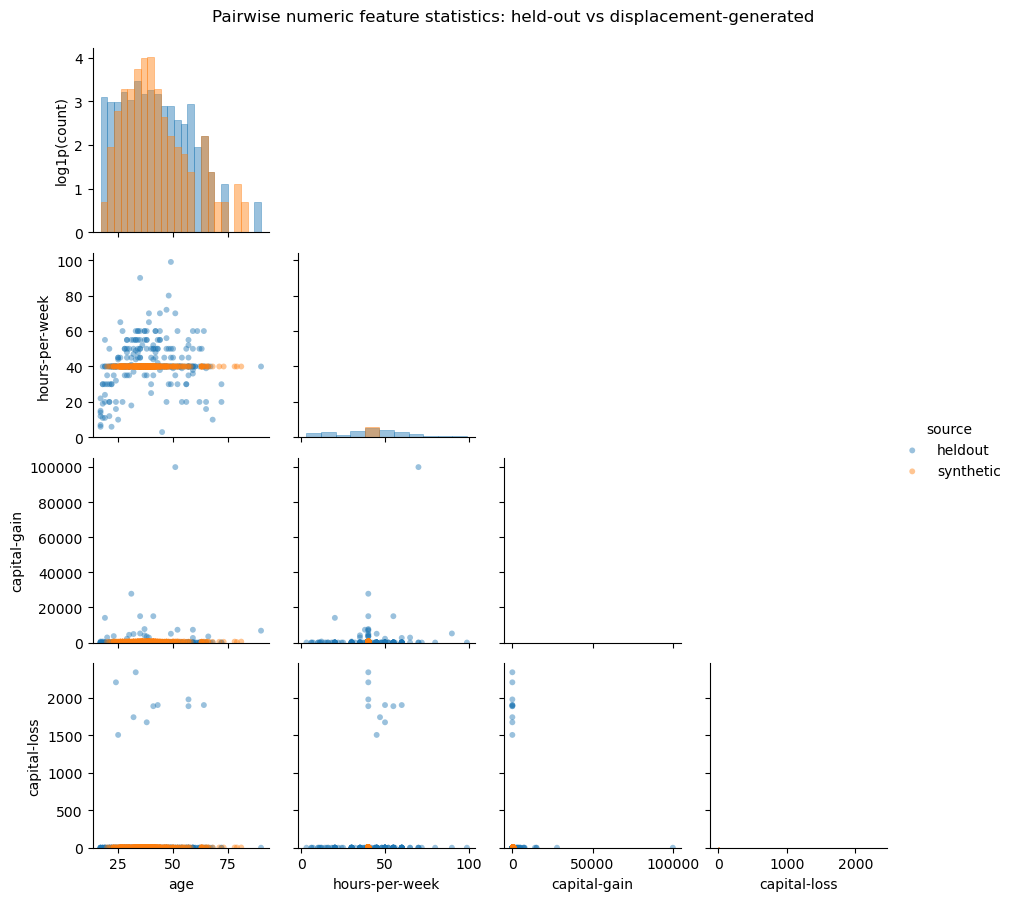

In [11]:
pair_grid = pairwise_feature_plot(
    test_df,
    synthetic,
    features=regression_columns,
    original_label="heldout",
    generated_label="synthetic",
    max_rows_per_source=300,
    random_state=RANDOM_STATE,
)
pair_grid.fig.suptitle("Pairwise numeric feature statistics: held-out vs displacement-generated", y=1.02)
